<a href="https://colab.research.google.com/github/ai1108/aud-usd-exchange-rate-forecasting/blob/main/aud_usd_exchange_rate_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.雙邊匯率資料分析-AUD/USD WK4-WK13**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/weekly.csv', parse_dates=['Date'])

print(data)

        Date   Price    Open    High     Low  Vol. Change %
0 2025-12-07  0.6668  0.6637  0.6686  0.6610   NaN    0.42%
1 2025-11-30  0.6640  0.6550  0.6650  0.6532   NaN    1.37%
2 2025-11-23  0.6550  0.6453  0.6561  0.6436   NaN    1.46%
3 2025-11-16  0.6456  0.6533  0.6540  0.6421   NaN   -1.24%
4 2025-11-09  0.6537  0.6492  0.6582  0.6488   NaN    0.66%
5 2025-11-02  0.6494  0.6548  0.6563  0.6458   NaN   -0.79%
6 2025-10-26  0.6546  0.6526  0.6619  0.6525   NaN    0.49%
7 2025-10-19  0.6514  0.6483  0.6531  0.6472   NaN    0.26%
8 2025-10-12  0.6497  0.6503  0.6534  0.6440   NaN    0.39%
9 2025-10-05  0.6472  0.6598  0.6626  0.6472   NaN   -2.00%


In [ ]:
data['Change_pct'] = data['Change %'].str.replace('%','').astype(float)

data['Range'] = data['High'] - data['Low']

data['Trend'] = data['Price'].diff()
data['Trend_label'] = data['Trend'].apply(lambda x: 'Appreciation' if x>0 else ('Depreciation' if x<0 else 'Flat'))

data = data.sort_values('Date', ascending=True).reset_index(drop=True)

data['Week'] = ['WK'+str(i+4) for i in range(len(data))]

data.set_index('Week', inplace=True)

print("Weekly Exchange Rate Statistics:")
print(data[['Date','Price','High','Low','Range','Change_pct','Trend_label']])

Weekly Exchange Rate Statistics:
           Date   Price    High     Low   Range  Change_pct   Trend_label
Week                                                                     
WK4  2025-10-05  0.6472  0.6626  0.6472  0.0154       -2.00  Depreciation
WK5  2025-10-12  0.6497  0.6534  0.6440  0.0094        0.39  Depreciation
WK6  2025-10-19  0.6514  0.6531  0.6472  0.0059        0.26  Depreciation
WK7  2025-10-26  0.6546  0.6619  0.6525  0.0094        0.49  Appreciation
WK8  2025-11-02  0.6494  0.6563  0.6458  0.0105       -0.79  Depreciation
WK9  2025-11-09  0.6537  0.6582  0.6488  0.0094        0.66  Appreciation
WK10 2025-11-16  0.6456  0.6540  0.6421  0.0119       -1.24  Depreciation
WK11 2025-11-23  0.6550  0.6561  0.6436  0.0125        1.46  Depreciation
WK12 2025-11-30  0.6640  0.6650  0.6532  0.0118        1.37  Depreciation
WK13 2025-12-07  0.6668  0.6686  0.6610  0.0076        0.42          Flat


In [ ]:
import pandas as pd

data = pd.read_csv("weekly.csv")

data["Date"] = pd.to_datetime(data["Date"], format="mixed")

data = data.sort_values(by="Date", ascending=True).reset_index(drop=True)

num_weeks = len(data)
week_labels = [f"WK{4 + i}" for i in range(num_weeks)]
data["Week"] = week_labels

print(data[["Week", "Date", "Price", "High", "Low"]])

   Week       Date   Price    High     Low
0   WK4 2025-10-05  0.6472  0.6626  0.6472
1   WK5 2025-10-12  0.6497  0.6534  0.6440
2   WK6 2025-10-19  0.6514  0.6531  0.6472
3   WK7 2025-10-26  0.6546  0.6619  0.6525
4   WK8 2025-11-02  0.6494  0.6563  0.6458
5   WK9 2025-11-09  0.6537  0.6582  0.6488
6  WK10 2025-11-16  0.6456  0.6540  0.6421
7  WK11 2025-11-23  0.6550  0.6561  0.6436
8  WK12 2025-11-30  0.6640  0.6650  0.6532
9  WK13 2025-12-07  0.6668  0.6686  0.6610


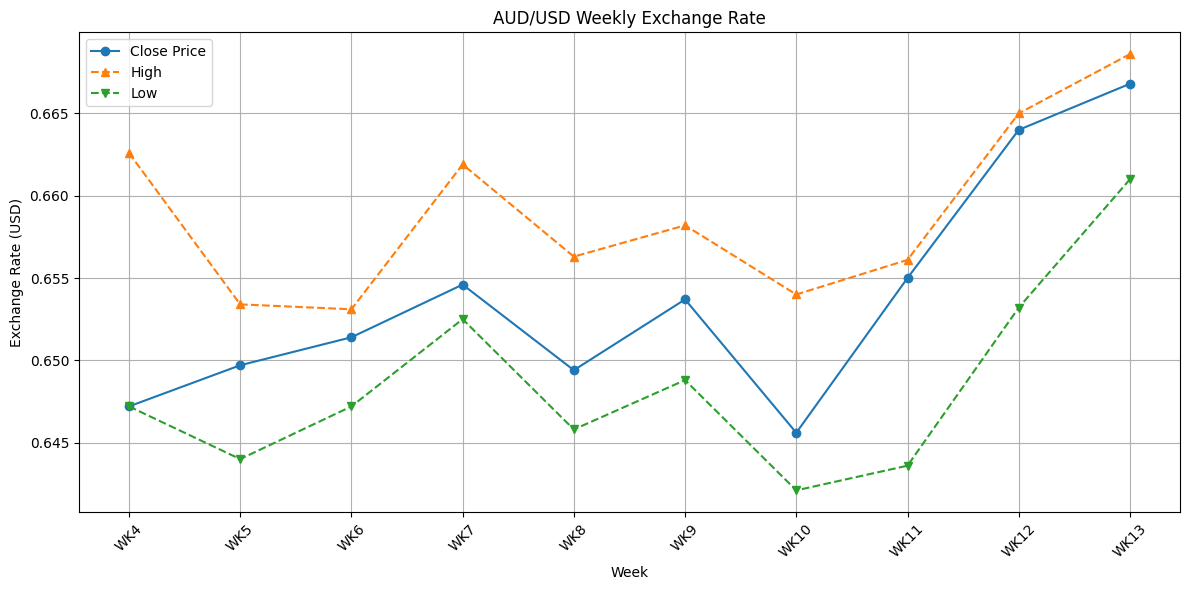


Weekly Trend Analysis:
WK4 (2025-10-05): Close Price 0.6472, Range 0.0154, Change -1.91%, Trend Down
WK5 (2025-10-12): Close Price 0.6497, Range 0.0094, Change -0.09%, Trend Down
WK6 (2025-10-19): Close Price 0.6514, Range 0.0059, Change 0.48%, Trend Up
WK7 (2025-10-26): Close Price 0.6546, Range 0.0094, Change 0.31%, Trend Up
WK8 (2025-11-02): Close Price 0.6494, Range 0.0105, Change -0.82%, Trend Down
WK9 (2025-11-09): Close Price 0.6537, Range 0.0094, Change 0.69%, Trend Up
WK10 (2025-11-16): Close Price 0.6456, Range 0.0119, Change -1.18%, Trend Down
WK11 (2025-11-23): Close Price 0.655, Range 0.0125, Change 1.5%, Trend Up
WK12 (2025-11-30): Close Price 0.664, Range 0.0118, Change 1.37%, Trend Up
WK13 (2025-12-07): Close Price 0.6668, Range 0.0076, Change 0.47%, Trend Up


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("weekly.csv")

data["Date"] = pd.to_datetime(data["Date"], format="mixed")

data = data.sort_values(by="Date", ascending=True).reset_index(drop=True)

num_weeks = len(data)
data["Week"] = [f"WK{4 + i}" for i in range(num_weeks)]

data['Range'] = data['High'] - data['Low']

data['Change_pct'] = ((data['Price'] - data['Open']) / data['Open'] * 100).round(2)

def trend_label(row):
    if row['Change_pct'] > 0:
        return 'Up'
    elif row['Change_pct'] < 0:
        return 'Down'
    else:
        return 'Stable'

data['Trend_label'] = data.apply(trend_label, axis=1)

plt.figure(figsize=(12,6))
plt.plot(data["Week"], data['Price'], marker='o', label='Close Price')
plt.plot(data["Week"], data['High'], marker='^', linestyle='--', label='High')
plt.plot(data["Week"], data['Low'], marker='v', linestyle='--', label='Low')
plt.title('AUD/USD Weekly Exchange Rate')
plt.xlabel('Week')
plt.ylabel('Exchange Rate (USD)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nWeekly Trend Analysis:")
for i, row in data.iterrows():
    print(f"{row['Week']} ({row['Date'].date()}): Close Price {row['Price']}, Range {row['Range']:.4f}, Change {row['Change_pct']}%, Trend {row['Trend_label']}")

# **2.未來雙邊匯率模型預測-AUD/USD**

# 套件匯入

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Install pmdarima if not already installed and then import
try:
    import pmdarima as pm # Import pmdarima as pm
    from pmdarima import auto_arima
except ImportError:
    print("pmdarima not found. Installing pmdarima...")
    !pip install pmdarima
    import pmdarima as pm # Try importing again after installation
    from pmdarima import auto_arima

pmdarima not found. Installing pmdarima...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.0 MB/s eta 0:00:00


# 讀取資料

In [ ]:
data = pd.read_csv('/content/AUDUSD_Monthly_2000.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# 月資料 → 設定為每個月頻率，並線性補齊缺缺值
data = data.asfreq('M')
data['AUD_USD'] = data['AUD_USD'].interpolate(method='linear')
print(data.head())

            AUD_USD
Date               
2000-01-31   0.6382
2000-02-29   0.6143
2000-03-31   0.6055
2000-04-30   0.5909
2000-05-31   0.5735


/tmp/ipython-input-2567349933.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.asfreq('M')


# ACF / PACF（模型判別參考）

<Figure size 1000x400 with 0 Axes>

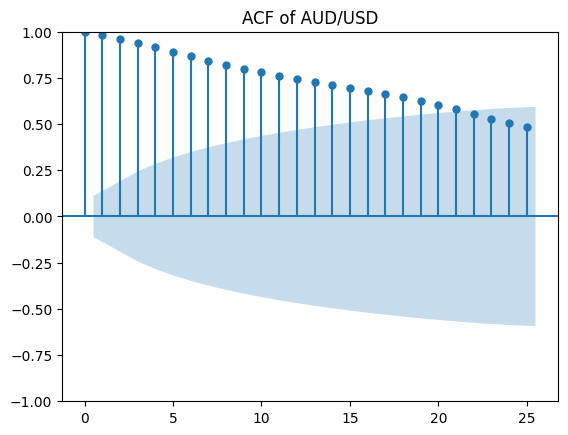

<Figure size 1000x400 with 0 Axes>

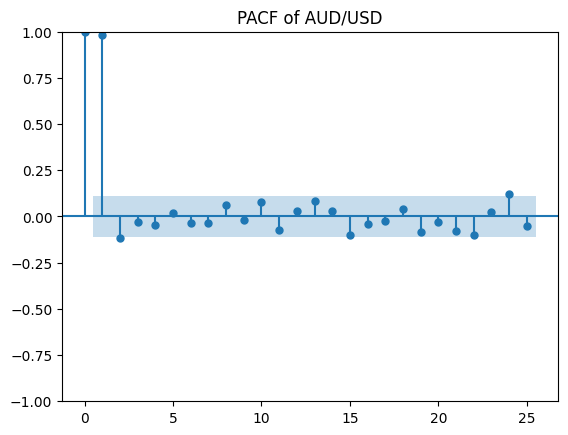

In [ ]:
plt.figure(figsize=(10,4))
plot_acf(data['AUD_USD'])
plt.title("ACF of AUD/USD")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(data['AUD_USD'])
plt.title("PACF of AUD/USD")
plt.show()

圖一（ACF）分析：


Lag 0–20 的棒子都超過藍色底，顯著。


Lag 20–25 的棒子落入藍色底，不顯著。


Lag 0 的棒子必然為 1。


棒子隨著 lag 增加逐漸下降，呈現拖尾（tailing off），即慢慢下降而非突然截尾，顯示資料可能存在趨勢或非平穩性。


大部分 lag 都顯著，表示歷史影響力較長（長記憶）。


解讀：


ACF 顯示序列值與滯後值的相關性，ACF 衰減緩慢是非平穩序列（Non-Stationary Series）的典型特徵。


AUD/USD 匯率序列可能具有趨勢或單根。



圖二（PACF）分析：


Lag 1 的棒子顯著超出藍色底，Lag 0 為 1（完全相關）。


Lag 2–25 幾乎落入藍色底，不顯著。


唯一例外：Lag 22 約 0.2，影響很小，可忽略。


PACF 呈截尾（cut-off）現象：Lag 1 後快速落入置信區間，AR 成分主要集中在前期。


解讀：


PACF 顯示序列值與滯後值之間的直接相關性，排除中間滯後的間接影響。


當前值主要受前一期值直接影響，序列依賴性集中於 Lag 1。




# 訓練集 / 驗證集切分

In [ ]:
train = data[:'2024-12-31']
valid = data['2025-01-31':]

results = {}   # 存放各模型 RMSE 與預測

# ARIMA 模型

In [ ]:
print("Fitting ARIMA model...")

arima_auto = auto_arima(
    train['AUD_USD'],
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    max_p=5, max_q=5
)

best_order = arima_auto.order
print("Best ARIMA order:", best_order)

# 正式建立 ARIMA 模型（使用 statespace 提升穩定性）
model_arima = ARIMA(train['AUD_USD'], order=best_order).fit(method='statespace')

# 驗證集預測
pred_arima = model_arima.forecast(steps=len(valid))

rmse_arima = np.sqrt(mean_squared_error(valid['AUD_USD'], pred_arima))
results['ARIMA'] = {'model': model_arima, 'rmse': rmse_arima, 'pred': pred_arima}

print("ARIMA RMSE:", rmse_arima)

Fitting ARIMA model...
Best ARIMA order: (0, 1, 0)
ARIMA RMSE: 0.025495396643315817


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# ETS（指數平滑）

In [ ]:
print("Fitting ETS model...")

ets_model = ExponentialSmoothing(train['AUD_USD'], trend='add', seasonal=None).fit()
pred_ets = ets_model.forecast(len(valid))

rmse_ets = np.sqrt(mean_squared_error(valid['AUD_USD'], pred_ets))
results['ETS'] = {'model': ets_model, 'rmse': rmse_ets, 'pred': pred_ets}

print("ETS RMSE:", rmse_ets)

Fitting ETS model...
ETS RMSE: 0.025829557305422843


# Naive（隨機漫步）

In [ ]:
naive_pred = pd.Series(train['AUD_USD'].iloc[-1], index=valid.index)
rmse_naive = np.sqrt(mean_squared_error(valid['AUD_USD'], naive_pred))

results['Naive'] = {'model': 'Naive', 'rmse': rmse_naive, 'pred': naive_pred}

print("Naive RMSE:", rmse_naive)

Naive RMSE: 0.025495396643315817


# Seasonal Naive（去年同月）

In [ ]:
snaive_pred = pd.Series(
    train['AUD_USD'][-12:].values[:len(valid)],
    index=valid.index
)

rmse_snaive = np.sqrt(mean_squared_error(valid['AUD_USD'], snaive_pred))

results['SNaive'] = {'model': 'SNaive', 'rmse': rmse_snaive, 'pred': snaive_pred}

print("SNaive RMSE:", rmse_snaive)

SNaive RMSE: 0.02121006836386908


# 比較 RMSE → 選最佳模型

In [ ]:
best_model_name = min(results, key=lambda x: results[x]['rmse'])
best_model_info = results[best_model_name]

print(f"最佳模型：{best_model_name}")
print(f"RMSE：{best_model_info['rmse']:.6f}")

最佳模型：SNaive
RMSE：0.021210


# 未來多步預測

In [ ]:
forecast_steps = 12   # 你可自己改預測未來期數

last_date = train.index[-1] # Modified from data.index[-1] to train.index[-1]
future_index = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=forecast_steps, freq='ME') # freq='M' changed to freq='ME'

# 依據最佳模型預測未來
if best_model_name == 'ARIMA':
    future_forecast = best_model_info['model'].forecast(steps=forecast_steps)

elif best_model_name == 'ETS':
    future_forecast = best_model_info['model'].forecast(forecast_steps)

elif best_model_name == 'Naive':
    future_forecast = pd.Series(train['AUD_USD'].iloc[-1], index=future_index)

elif best_model_name == 'SNaive':
    future_forecast = pd.Series(train['AUD_USD'][-12:].values[:forecast_steps],
                                index=future_index)

# 歷史 + 未來預測

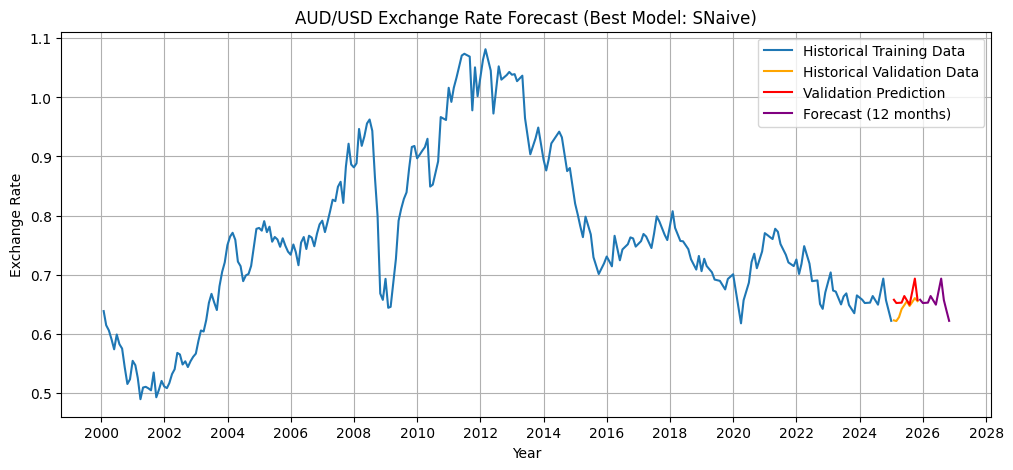

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # 匯入日期處理模組

plt.figure(figsize=(12,5))
plt.plot(train.index, train['AUD_USD'], label='Historical Training Data')
plt.plot(valid.index, valid['AUD_USD'], label='Historical Validation Data', color='orange') # 保持橘色
plt.plot(valid.index, best_model_info['pred'], color='red', label='Validation Prediction')

plt.plot(future_forecast.index, future_forecast, label=f'Forecast ({forecast_steps} months)', color='purple')

plt.title(f'AUD/USD Exchange Rate Forecast (Best Model: {best_model_name})')
plt.xlabel('Year')
plt.ylabel('Exchange Rate')

# 獲取當前的 Axes 物件 (Axle Object)，以便對軸進行細部控制
ax = plt.gca()
# 設定主要刻度定位器 (Major Locator) 為每兩年一個刻度
# YearLocator(2) 確保了刻度點的間隔為兩年
ax.xaxis.set_major_locator(mdates.YearLocator(2))
# 設定刻度標籤的格式為年份 (例如: 2020, 2022, ...)，這是 DateFormatter('%Y') 的功能
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


plt.grid(True)
plt.legend()
plt.show()

/tmp/ipython-input-1451977657.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.asfreq('M')


Train size: 300
Validation size: 10
Fitting ARIMA model...
Best ARIMA order: (0, 1, 0)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-1451977657.py:87: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),


ARIMA RMSE: 0.025495396643315817
Fitting ETS model...
ETS RMSE: 0.025829557305422843
Naive RMSE: 0.025495396643315817
SNaive RMSE: 0.02121006836386908

最佳模型：SNaive
RMSE：0.021210



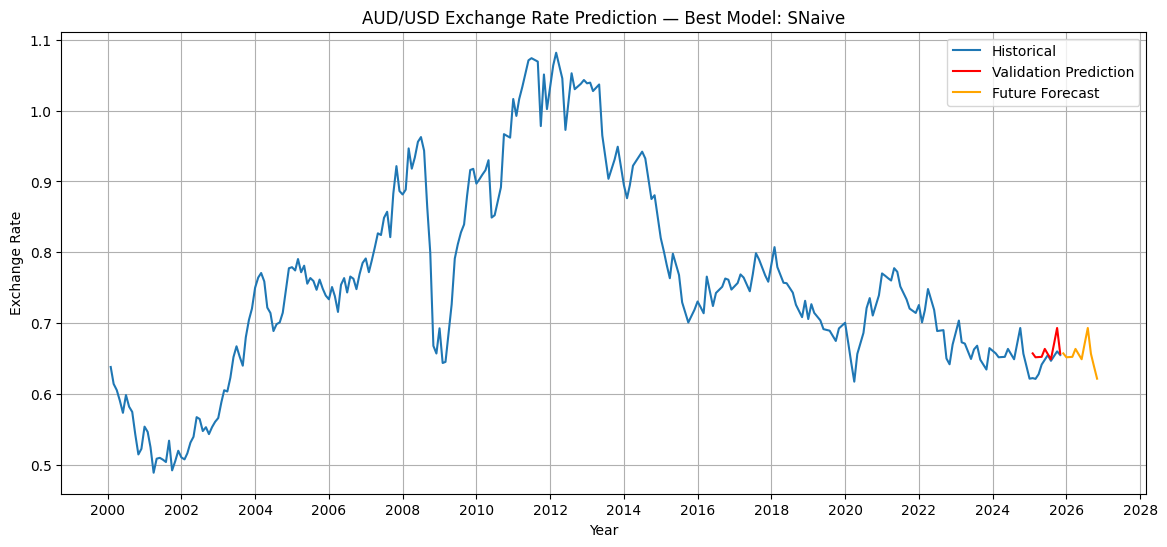

In [ ]:
# Step 0: 套件匯入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # 【新增】匯入日期處理模組
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# Step 1: 讀取資料
data = pd.read_csv('/content/AUDUSD_Monthly_2000.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data = data.sort_index()

# 月頻率，補齊缺值
data = data.asfreq('M')
data['AUD_USD'] = data['AUD_USD'].interpolate(method='linear')

# Step 2: 訓練 / 驗證切分
train = data[:'2024-12-31']
valid = data['2025-01-31':]

print("Train size:", len(train))
print("Validation size:", len(valid))

results = {}

# Step 3: ARIMA
print("Fitting ARIMA model...")
arima_model = auto_arima(train['AUD_USD'], seasonal=False, stepwise=True,
                         suppress_warnings=True)
best_order = arima_model.order
print("Best ARIMA order:", best_order)

model_arima = ARIMA(train['AUD_USD'], order=best_order).fit()
pred_arima = pd.Series(model_arima.forecast(steps=len(valid)), index=valid.index)
rmse_arima = np.sqrt(mean_squared_error(valid['AUD_USD'], pred_arima))
results['ARIMA'] = {'model': model_arima, 'rmse': rmse_arima, 'pred': pred_arima}
print("ARIMA RMSE:", rmse_arima)


# Step 4: ETS（含 Trend）
print("Fitting ETS model...")
ets_model = ExponentialSmoothing(train['AUD_USD'], trend='add', seasonal=None).fit()
pred_ets = pd.Series(ets_model.forecast(len(valid)), index=valid.index)
rmse_ets = np.sqrt(mean_squared_error(valid['AUD_USD'], pred_ets))
results['ETS'] = {'model': ets_model, 'rmse': rmse_ets, 'pred': pred_ets}
print("ETS RMSE:", rmse_ets)


# Step 5: Naive（隨機漫步）
naive_pred = pd.Series(train['AUD_USD'].iloc[-1], index=valid.index)
rmse_naive = np.sqrt(mean_squared_error(valid['AUD_USD'], naive_pred))
results['Naive'] = {'model': 'Naive', 'rmse': rmse_naive, 'pred': naive_pred}
print("Naive RMSE:", rmse_naive)


# Step 6: SNaive（12期季節性）
seasonal_period = 12
snaive_values = []
for i in range(len(valid)):
    snaive_values.append(train['AUD_USD'].iloc[-seasonal_period + i % seasonal_period])
snaive_pred = pd.Series(snaive_values, index=valid.index)
rmse_snaive = np.sqrt(mean_squared_error(valid['AUD_USD'], snaive_pred))
results['SNaive'] = {'model': 'SNaive', 'rmse': rmse_snaive, 'pred': snaive_pred}
print("SNaive RMSE:", rmse_snaive)

# Step 7: 選擇最佳模型
best_model_name = min(results, key=lambda x: results[x]['rmse'])
best_result = results[best_model_name]

print("\n==============================")
print(f"最佳模型：{best_model_name}")
print(f"RMSE：{best_result['rmse']:.6f}")
print("==============================\n")

best_model = best_result['model']
best_pred = best_result['pred']

# Step 8: 未來預測（可調整）
forecast_steps = 12  # ← 自訂預測期數（例如 12 個月）
last_date = data.index[-1]
future_index = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=forecast_steps, freq='M')

if best_model_name == 'ARIMA':
    future_forecast = pd.Series(best_model.forecast(steps=forecast_steps), index=future_index)
elif best_model_name == 'ETS':
    future_forecast = pd.Series(best_model.forecast(forecast_steps), index=future_index)
elif best_model_name == 'Naive':
    future_forecast = pd.Series(train['AUD_USD'].iloc[-1], index=future_index)
elif best_model_name == 'SNaive':
    snaive_future = []
    for i in range(forecast_steps):
        snaive_future.append(train['AUD_USD'].iloc[-seasonal_period + i % seasonal_period])
    future_forecast = pd.Series(snaive_future, index=future_index)

# Step 9: 繪圖
plt.figure(figsize=(14,6))
plt.plot(data.index, data['AUD_USD'], label='Historical')
plt.plot(valid.index, best_pred, label='Validation Prediction', color='red')
plt.plot(future_forecast.index, future_forecast, label='Future Forecast', color='orange')
plt.title(f'AUD/USD Exchange Rate Prediction — Best Model: {best_model_name}')
plt.xlabel('Year')
plt.ylabel('Exchange Rate')

# 1. 獲取當前的 Axes 物件 (Axis Object)
ax = plt.gca()
# 2. 設定主要刻度定位器 (Major Locator) 為每兩年一個刻度
# 這有助於在長期時間序列分析中，避免 x 軸標籤過於擁擠 (cluttering)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
# 3. 設定刻度標籤的格式為年份 (例如: 2000, 2002, 2004, ...)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/real.csv')

# 查看資料
print(data.head())

  日期 (Date)  開盤價 (Open)  預計低點 (Low)  預計高點 (High)  預計收盤價 (Close)  Unnamed: 5
0    Dec-25       0.651       0.633        0.663          0.651         NaN
1    Jan-26       0.651       0.634        0.654          0.644         NaN
2    Feb-26       0.644       0.641        0.661          0.651         NaN
3    Mar-26       0.651       0.651        0.673          0.663         NaN
4    Apr-26       0.663       0.637        0.663          0.647         NaN



Corrected Combined data:
            Model_Forecast  Real_Forecast
2025-12-01         0.65190          0.651
2026-01-01         0.65220          0.644
2026-02-01         0.65250          0.651
2026-03-01         0.66370          0.663
2026-04-01         0.65640          0.647
2026-05-01         0.64910          0.662
2026-06-01         0.67115          0.665
2026-07-01         0.69320          0.682
2026-08-01         0.65690          0.686
2026-09-01         0.63930          0.686
2026-10-01         0.62170          0.689
2026-11-01             NaN          0.668
2026-12-01             NaN          0.661
NaT                    NaN            NaN
NaT                    NaN            NaN
NaT                    NaN            NaN
NaT                    NaN            NaN
NaT                    NaN            NaN
NaT                    NaN            NaN
NaT                    NaN            NaN
NaT                    NaN            NaN
NaT                    NaN            NaN
NaT     

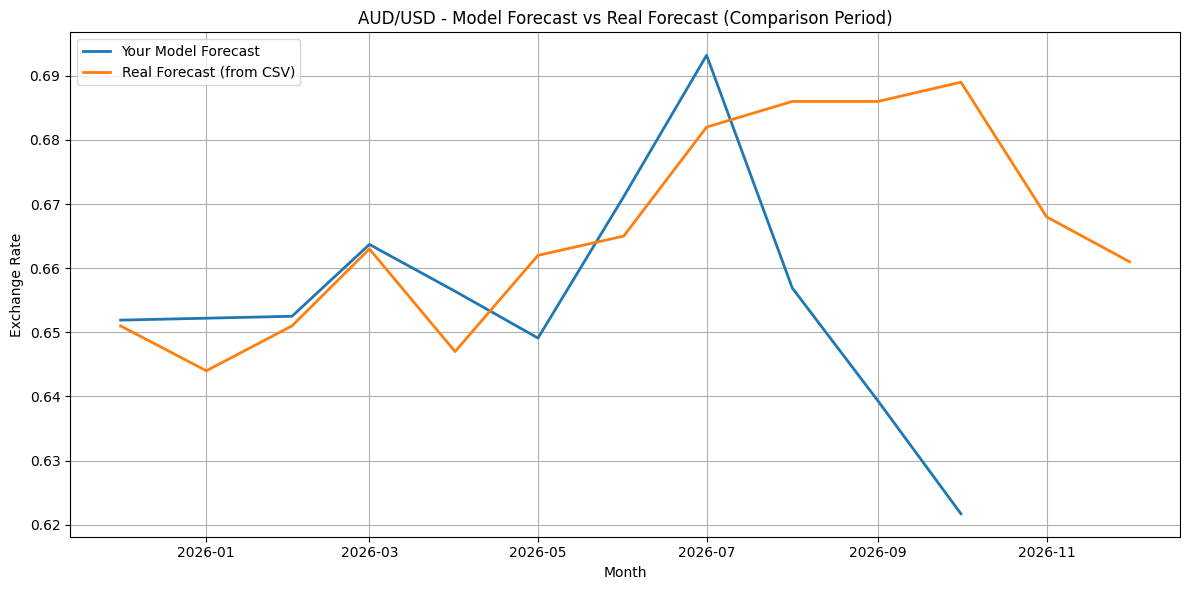

In [ ]:
# 1. 載入並處理 real.csv 資料以定義 real_close
real_data = pd.read_csv('/content/real.csv')

real_data['Date'] = pd.to_datetime(real_data['日期 (Date)'], format='%b-%y')

real_close = real_data.set_index('Date')['預計收盤價 (Close)']

real_close.index = real_close.index.to_period('M').to_timestamp(how='start')
real_close.name = "Real_Forecast"

# 2. 統一模型預測日期格式（每月 1 號）
model_pred = future_forecast.copy()
model_pred.index = model_pred.index.to_period('M').to_timestamp(how='start')
model_pred.name = "Model_Forecast"

target_index = real_close.index

model_pred_filtered = model_pred[model_pred.index.isin(target_index)]
model_pred_filtered.name = "Model_Forecast"

# 3. 合併
combined = pd.concat([model_pred_filtered, real_close], axis=1)

combined['Model_Forecast'] = pd.to_numeric(combined['Model_Forecast'], errors='coerce')
print("\nCorrected Combined data:")
print(combined)

# 4. 畫比較圖
plt.figure(figsize=(12,6))

plt.plot(combined.index, combined['Model_Forecast'], label='Your Model Forecast', linewidth=2)

plt.plot(combined.index, combined['Real_Forecast'], label='Real Forecast (from CSV)', linewidth=2)

plt.title("AUD/USD - Model Forecast vs Real Forecast (Comparison Period)")
plt.xlabel("Month")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# **圖片：經常帳GDP佔比對匯率**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/content/2000.csv')

# 查看資料
print(data.head())

         Date   Price    Open    High     Low  Vol. Change %
0  11/01/2025  0.6432  0.6545  0.6581  0.6423   NaN   -1.74%
1  10/01/2025  0.6546  0.6613  0.6630  0.6440   NaN   -1.03%
2  09/01/2025  0.6614  0.6538  0.6708  0.6483   NaN    1.12%
3  08/01/2025  0.6541  0.6426  0.6570  0.6414   NaN    1.79%
4  07/01/2025  0.6426  0.6577  0.6626  0.6424   NaN   -2.36%


In [ ]:
import pandas as pd

df = pd.read_csv('/content/current.csv')

# 保留第二行（index=1），因為它才是真正的資料列
row = df.iloc[1]

# 轉成 long format
data_current = pd.DataFrame({
    "Year": row.index[1:],      # 去掉第一欄名稱欄
    "Value": row.values[1:]
})

# 把 Year 轉數字，把 Value 轉 float
data_current["Year"] = data_current["Year"].astype(int)
data_current["Value"] = pd.to_numeric(data_current["Value"], errors='coerce')

print(data_current.head())

   Year  Value
0  2000   -4.0
1  2001   -2.2
2  2002   -3.8
3  2003   -5.3
4  2004   -6.3


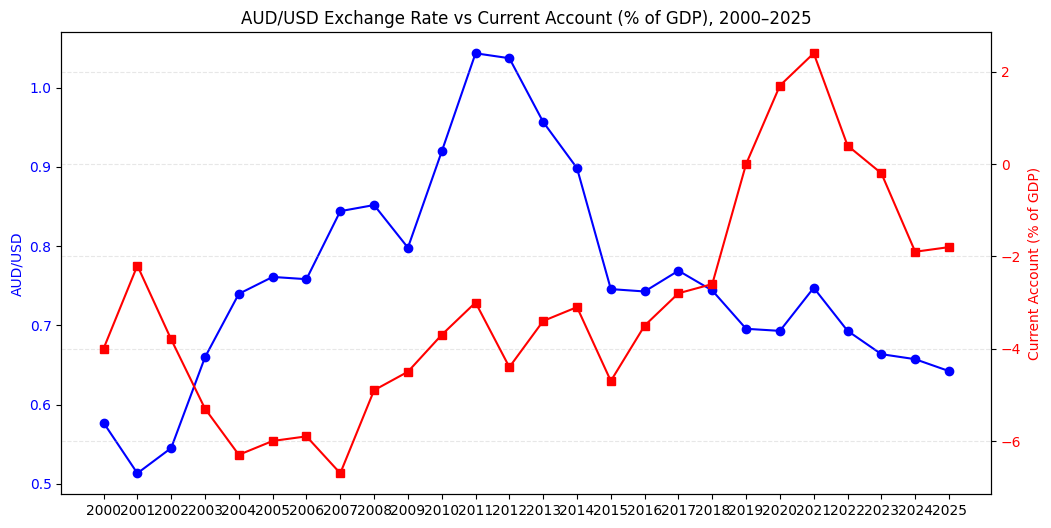

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fx = pd.read_csv('/content/2000.csv')

fx['Date'] = pd.to_datetime(fx['Date'], format="%m/%d/%Y")

fx = fx[['Date', 'Price']].sort_values('Date')

# 取年份欄（方便跟經常帳資料對齊）
fx['Year'] = fx['Date'].dt.year

df = pd.read_csv('/content/current.csv')

row = df.iloc[1]  # 第二列才是真正數據

data_current = pd.DataFrame({
    "Year": row.index[1:],
    "Value": row.values[1:]
})

data_current["Year"] = data_current["Year"].astype(int)
data_current["Value"] = pd.to_numeric(data_current["Value"], errors='coerce')
data_current = data_current.dropna()

years = list(range(2000, 2026))

# 每年平均匯率（因為匯率是月資料）
fx_yearly = fx.groupby("Year")["Price"].mean().reindex(years)

# 經常帳資料對齊
ca_yearly = data_current.set_index("Year")["Value"].reindex(years)

plt.figure(figsize=(12, 6))

ax1 = plt.gca()

# --- 左軸 AUD/USD 年均 ---
ax1.plot(years, fx_yearly, color='blue', marker='o', label='AUD/USD (Yearly Avg)')
ax1.set_ylabel("AUD/USD", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# --- 右軸經常帳 ---
ax2 = ax1.twinx()
ax2.plot(years, ca_yearly, color='red', marker='s', label='Current Account (% GDP)')
ax2.set_ylabel("Current Account (% of GDP)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# X 軸年份
plt.xticks(years, rotation=45)

plt.title("AUD/USD Exchange Rate vs Current Account (% of GDP), 2000–2025")
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()
